# CISM Tutorial 02: FANMOD+, Initialization, And Stringency Selection

This notebook starts from the output of tutorial 01.

By the end of this notebook you should have:

- a validated prepared dataset folder
- a loaded `CISM` object
- a `TissueStateDiscriminativeMotifs` object
- a discriminative-motifs-versus-stringency plot
- an AUC-based choice of stringency parameters
- a direct asymmetric majority/minority stringency analysis
- a serialized artifact you can load in later analysis notebooks

## What This Notebook Covers

This notebook performs the transition from prepared graph txt files to an analysis-ready CISM state.

It will:

1. reuse the `network_dataset_root_path` and `dataset_folder` from tutorial 01
2. resolve the FANMOD+ binary already bundled in this repository
3. create tutorial-local `fanmod_output` and `fanmod_cache` folders
4. initialize `CISM`
5. load the prepared dataset
6. construct a discriminator
7. inspect discriminative motifs versus stringency
8. choose a stringency parameter using Random Forest ROC AUC
9. save a reusable pickle artifact for downstream notebooks

## Notes About FANMOD+ Binaries

This tutorial uses the FANMOD+ binaries already stored under `cism/FANMOD_binaries/`.

For tutorial purposes this is simpler and safer than moving them now, because the notebook can stay fully self-contained and directly point `CISM` to the repo-bundled executable.

In [1]:
from pathlib import Path
import pickle
import platform

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

from cism import (
    CISM,
    DiscriminativeFeatureKey,
    HardDiscriminativeFC,
    TissueStateDiscriminativeMotifs,
    build_patient_motif_matrix,
    validate_network_dataset_directory,
)


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "tutorials" else Path.cwd().resolve()
TUTORIALS_DIR = PROJECT_ROOT / "melanoma_tutorials"
TUTORIAL_RUNTIME_DIR = TUTORIALS_DIR / "runtime"
FANMOD_OUTPUT_ROOT = TUTORIAL_RUNTIME_DIR / "fanmod_output"
FANMOD_CACHE_ROOT = TUTORIAL_RUNTIME_DIR / "fanmod_cache"
SERIALIZED_ROOT = TUTORIAL_RUNTIME_DIR / "serialized"
ASYMMETRIC_STRINGENCY_ROOT = TUTORIAL_RUNTIME_DIR / "asymmetric_stringency"

FANMOD_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FANMOD_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
SERIALIZED_ROOT.mkdir(parents=True, exist_ok=True)
ASYMMETRIC_STRINGENCY_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Tutorial runtime directory: {TUTORIAL_RUNTIME_DIR}")
print(f"fanmod_output_root_path: {FANMOD_OUTPUT_ROOT}")
print(f"fanmod_cache_root_path: {FANMOD_CACHE_ROOT}")
print(f"serialized artifact directory: {SERIALIZED_ROOT}")


Project root: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials
Tutorial runtime directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime
fanmod_output_root_path: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/fanmod_output
fanmod_cache_root_path: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/fanmod_cache
serialized artifact directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/serialized


## Paste The Handoff Values From Tutorial 01

At the end of tutorial 01, the notebook printed these exact values:

- `network_dataset_root_path`
- `dataset_folder`

Use them directly here.

In [3]:
# Replace these with the values printed at the end of tutorial 01.
network_dataset_root_path = str(PROJECT_ROOT / "pet_data")
dataset_folder = "Melanoma"  # Change this to the name of your dataset folder if it's different.

dataset_dir = Path(network_dataset_root_path) / dataset_folder
print(f"network_dataset_root_path = {network_dataset_root_path}")
print(f"dataset_folder = {dataset_folder}")
print(f"dataset_dir = {dataset_dir}")


network_dataset_root_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/pet_data
dataset_folder = Melanoma
dataset_dir = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/pet_data/Melanoma


In [4]:
# Confirm that tutorial 01 produced a valid folder.
txt_files = validate_network_dataset_directory(dataset_dir, require_patient_class=True)
print(f"Validated {len(txt_files)} txt graph files in {dataset_dir}")


Validated 177 txt graph files in /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/pet_data/Melanoma


## Resolve The FANMOD+ Binary

The `CISM` object expects:

- `fanmod_path`: directory containing the binary
- `fanmod_exe`: the executable filename

In [5]:
fanmod_path = PROJECT_ROOT/ ".." / "FANMOD_binaries"
if platform.system().lower().startswith("win"):
    fanmod_exe = "LocalFANMOD - Windows"
else:
    fanmod_exe = "LocalFANMOD"

fanmod_binary_path = fanmod_path / fanmod_exe
print(f"fanmod_path = {fanmod_path}")
print(f"fanmod_exe = {fanmod_exe}")
print(f"fanmod binary exists: {fanmod_binary_path.exists()}")
!chmod +x {fanmod_binary_path}  # Ensure the binary is executable.


fanmod_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/../FANMOD_binaries
fanmod_exe = LocalFANMOD
fanmod binary exists: True


## Initialize `CISM`

This tutorial uses the requested defaults:

- `motif_size = 4`
- `iterations = 1000`

In [6]:
cism = CISM(
    fanmod_exe=fanmod_exe,
    fanmod_path=str(fanmod_path),
    network_dataset_root_path=network_dataset_root_path,
    fanmod_output_root_path=str(FANMOD_OUTPUT_ROOT),
    fanmod_cache_root_path=str(FANMOD_CACHE_ROOT),
    motif_size=4,
    iterations=1000,
)

cism


## Load The Prepared Dataset

Use the requested defaults when adding the dataset:

- `force_run_fanmod=False`
- `force_parse=False`
- `n_jobs=1` to avoid memory-heavy process pools on the large melanoma motif table

In [7]:
# Replace dataset_type and dataset_name with the metadata you want in downstream analysis.
dataset_type = "Disease"
dataset_name = "Melanoma"

# Set these True after changing graph preparation or cell-type mapping so stale FANMOD/cache
# artifacts cannot be reused. After one clean rebuild, you may switch them back to False.
force_run_fanmod = False
force_parse = False
DATASET_N_JOBS = 1

cism.add_dataset(
    dataset_folder=dataset_folder,
    dataset_type=dataset_type,
    dataset_name=dataset_name,
    force_run_fanmod=force_run_fanmod,
    force_parse=force_parse,
    n_jobs=DATASET_N_JOBS,
    require_patient_class=True,
)


Running FANMOD:   0%|          | 0/177 [00:00<?, ?it/s]

Parsing FANMOD output:   0%|          | 0/177 [00:00<?, ?it/s]

In [8]:
motif_df = cism.motif_dataset()
print(f"Loaded motif rows: {0 if motif_df is None else len(motif_df)}")
display(motif_df.head() if motif_df is not None else None)


Loaded motif rows: 2017892


,Patient,FOV,ID,Freq,Count,Mean_Freq,STD,z_score,p_value,motif,nunique_colors,Disease,Patient_uId
0,100,FOV302,39807249708,0.056843,25282.0,1.115900e-02,4.331600e-04,105.470001,0.0,gASVWQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,Melanoma,Melanoma100
1,100,FOV302,39274052908,0.026189,11648.0,2.026400e-08,3.282600e-07,79780.000000,0.0,gASVdQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,Melanoma,Melanoma100
2,100,FOV302,5380271148,0.024233,10778.0,2.158800e-03,1.585800e-04,139.199997,0.0,gASVWQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,1,Melanoma,Melanoma100
3,100,FOV302,19676161324,0.014450,6427.0,5.053500e-03,1.634300e-04,57.497002,0.0,gASVWwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,Melanoma,Melanoma100
4,100,FOV302,5919756492,0.013787,6132.0,1.798800e-03,1.002600e-04,119.570000,0.0,gASVWwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,Melanoma,Melanoma100


## Define The Analysis Metadata Needed For Discrimination

To analyze discriminative motifs, we need:

- a path to `patient_class.csv`
- a mapping from raw class values to readable labels
- a mapping from integer cell-type ids to cell-type names

Both mappings are dataset-specific, so replace the examples below with your real values.

In [9]:
# This melanoma analysis focuses on the NN versus NP patient classes.
# Keep the survival helper below only for datasets that need a numeric survival split.
survival_rate_cutoff = 1000


def map_survival_rate_to_class(survival_rate: int):
    if survival_rate < survival_rate_cutoff:
        return "Short-term survival"
    return "Long-term survival"


labels = ["NN", "NP"]


In [10]:
tissue_state_csv_path = str(dataset_dir / "patient_class.csv")

# Use this mapping when patient_class.csv already contains readable categorical labels.
tissue_state_to_string = {
    "NP": "NP",
    "NN": "NN",
    "PN": "PN",
    "PP": "PP"
}

# Paste from tutorial 01 output. This is the graph color id -> cell-type name mapping.
common_cells_type = {0: 'DC', 1: 'b cell', 2: 'blood vessels', 3: 'cd4 apc', 4: 'cd4 t cell', 5: 'cd8 t cell', 6: 'gc', 7: 'hevs', 8: 'mac', 9: 'memory%cd4 t cell', 10: 'neutrophil', 11: 'nk cell', 12: 'stroma', 13: 'treg', 14: 'tumor', 15: 'unidentified'}

patient_class_df = pd.read_csv(tissue_state_csv_path, index_col=0, names=["class"])
analysis_patient_class_df = patient_class_df[patient_class_df["class"].isin(labels)].copy()
motif_patient_uids = set(motif_df["Patient_uId"].astype(str).unique())
missing_tissue_state = sorted(motif_patient_uids - set(patient_class_df.index.astype(str)))

print(f"Patients with motif rows: {len(motif_patient_uids)}")
print(f"Patients with tissue-state labels: {len(patient_class_df)}")
print(f"Patients in analysis labels {labels}: {len(analysis_patient_class_df)}")
display(analysis_patient_class_df["class"].value_counts().rename("patient_count"))
print(f"Patients without tissue-state labels and excluded from discrimination: {missing_tissue_state}")
print(f"labels = {labels}")
print("common_cells_type =")
print(common_cells_type)


Patients with motif rows: 68
Patients with tissue-state labels: 68
Patients in analysis labels ['NN', 'NP']: 38


class
NN    20
NP    18
Name: patient_count, dtype: int64

Patients without tissue-state labels and excluded from discrimination: []
labels = ['NN', 'NP']
common_cells_type =
{0: 'DC', 1: 'b cell', 2: 'blood vessels', 3: 'cd4 apc', 4: 'cd4 t cell', 5: 'cd8 t cell', 6: 'gc', 7: 'hevs', 8: 'mac', 9: 'memory%cd4 t cell', 10: 'neutrophil', 11: 'nk cell', 12: 'stroma', 13: 'treg', 14: 'tumor', 15: 'unidentified'}


In [11]:
discriminator = TissueStateDiscriminativeMotifs(
    cism=cism,
    tissue_state_csv_path=tissue_state_csv_path,
    tissue_state_to_string= tissue_state_to_string,  # Use tissue_state_to_string when labels are already categorical.
    common_cells_type=common_cells_type,
    #tissue_state_func=map_survival_rate_to_class,
    
)

display(discriminator.get_patients_class(classes=labels).groupby("patient_class").count())


,patient_class_id
patient_class,
NN,20
NP,18


## Plot Discriminative Motifs Per Stringency

This gives a first view of how many motifs remain as the discrimination stringency parameter increases.

Replace the colors if you prefer a different class palette.

/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


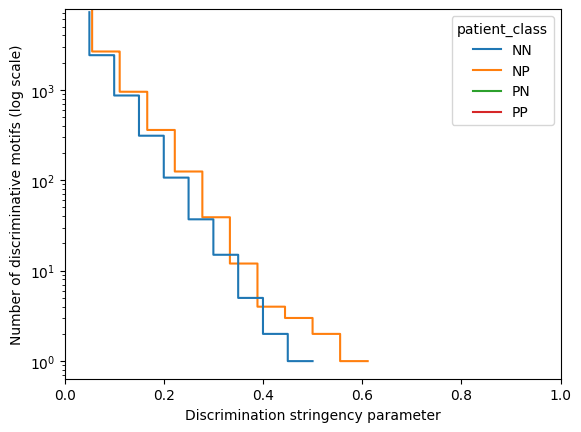

In [12]:
#warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

class_to_color = {
    "NN": "tab:blue",
    "NP": "tab:orange",
    "PN": "tab:green",
    "PP": "tab:red",
}

discover_result = discriminator.discover(
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    classes=labels,
)

discover_result.plot_number_of_motifs_versus_discrimination_stringency_parameter(
    class_to_color=class_to_color,
)


## Define A Feature Configuration Template

We will tune the main stringency controls used by the Random Forest validation:

- `shared_percentage`
- `max_class_features`

The configuration below is only the starting template. Optuna will search around it.

In [13]:
feature_conf_template = HardDiscriminativeFC(
    labels=labels,
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    use_cells_type_composition=False,
    use_motifs=True,
    shared_percentage=0.5,
    max_class_features=10,
)

feature_conf_template


## Choose The Best Stringency By Random Forest ROC AUC

This step uses the built-in Optuna tuner to search for a good stringency setting.

The objective is `roc_auc`, which is computed from the existing CISM motif-analysis pipeline.

In [14]:
# Avoid process-based parallelism here: the serialized CISM/motif state is large,
# and loky workers can be killed by memory pressure when n_jobs is high.
STRINGENCY_N_JOBS = 1
STRINGENCY_PREFER = "threads"

tuning_result = discriminator.tune_stringency(
    feature_conf=feature_conf_template,
    n_trials=3,
    metric="roc_auc",
    random_state=0,
    n_jobs=STRINGENCY_N_JOBS,
    prefer=STRINGENCY_PREFER,
    shared_percentage_range=(0.35, 0.5),
    max_class_features_range=(30, 30),
)

print("Best parameters:")
print(tuning_result.best_params)
print(f"Best ROC AUC: {tuning_result.best_score:.4f}")


[I 2026-06-10 11:36:13,482] A new study created in memory with name: no-name-ceed5e0c-21d8-43b6-961a-fa345859e78b


  0%|          | 0/38 [00:00<?, ?it/s]

[I 2026-06-10 11:37:47,964] Trial 0 finished with value: 0.7888888888888889 and parameters: {'shared_percentage': 0.4323220255890987, 'max_class_features': 30}. Best is trial 0 with value: 0.7888888888888889.


  0%|          | 0/38 [00:00<?, ?it/s]

[I 2026-06-10 11:39:21,896] Trial 1 finished with value: 0.8902777777777778 and parameters: {'shared_percentage': 0.4572784049558629, 'max_class_features': 30}. Best is trial 1 with value: 0.8902777777777778.


  0%|          | 0/38 [00:00<?, ?it/s]

[I 2026-06-10 11:40:57,069] Trial 2 finished with value: 0.7888888888888889 and parameters: {'shared_percentage': 0.4404145064107466, 'max_class_features': 30}. Best is trial 1 with value: 0.8902777777777778.


Best parameters:
{'shared_percentage': 0.4572784049558629, 'max_class_features': 30}
Best ROC AUC: 0.8903


In [15]:
tuning_trials_df = tuning_result.trials_dataframe()
display(tuning_trials_df)


,number,value,datetime_start,datetime_complete,duration,params_max_class_features,params_shared_percentage,state
0,0,0.788889,2026-06-10 11:36:13.483962,2026-06-10 11:37:47.964602,0 days 00:01:34.480640,30,0.432322,COMPLETE
1,1,0.890278,2026-06-10 11:37:47.965886,2026-06-10 11:39:21.896369,0 days 00:01:33.930483,30,0.457278,COMPLETE
2,2,0.788889,2026-06-10 11:39:21.897722,2026-06-10 11:40:57.069898,0 days 00:01:35.172176,30,0.440415,COMPLETE


## Build The Selected Analysis Configuration

We now convert the tuned parameters into the feature configuration we will carry into later notebooks.

In [16]:
best_feature_conf = HardDiscriminativeFC(
    labels=labels,
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    use_cells_type_composition=False,
    use_motifs=True,
    shared_percentage=tuning_result.best_params["shared_percentage"],
    max_class_features=tuning_result.best_params["max_class_features"],
)

best_feature_conf


## Asymmetric Discriminative Motif Stringency

The standard hard discriminative strategy is very strict about the opposite class. Here we keep the majority-class recurrence requirement, but allow a motif to appear in the minority class up to a tunable maximum.

This is independent of the soft motif scoring in tutorial 03b. It queries the CISM motif table directly, builds a patient-by-motif frequency matrix, and selects motifs by patient-level prevalence:

- `majority_min`: minimum prevalence in the motif's dominant class.
- `minority_max`: maximum allowed prevalence in the other class.

The direct query cell below answers: “which motifs fit these criteria?” The tuning cells then choose thresholds by leakage-safe LOOCV Random Forest ROC AUC.

In [17]:
def prepare_asymmetric_motif_matrix(discriminator, labels, p_value_threshold=0.05):
    patient_classes = discriminator.get_patients_class(labels)
    patient_classes = patient_classes.loc[~patient_classes.index.duplicated(keep="first")]
    motif_table = discriminator.cism.motifs_dataset.copy()
    if p_value_threshold is not None:
        motif_table = motif_table[motif_table["p_value"] < p_value_threshold]
    matrix = build_patient_motif_matrix(
        motif_table,
        patient_ids=patient_classes.index,
        motif_col="ID",
    )
    labels_series = patient_classes["patient_class"].reindex(matrix.index)
    return matrix, labels_series


def compute_asymmetric_prevalence(matrix, labels_series, label_order):
    label_0, label_1 = label_order
    group_0 = matrix.loc[labels_series == label_0]
    group_1 = matrix.loc[labels_series == label_1]

    prevalence_0 = (group_0 > 0).mean(axis=0).fillna(0.0)
    prevalence_1 = (group_1 > 0).mean(axis=0).fillna(0.0)
    mean_0 = group_0.mean(axis=0).fillna(0.0)
    mean_1 = group_1.mean(axis=0).fillna(0.0)
    group_1_dominant = (prevalence_1 > prevalence_0) | (
        np.isclose(prevalence_1, prevalence_0) & (mean_1 > mean_0)
    )

    prevalence = pd.DataFrame({"ID": matrix.columns})
    prevalence[f"{label_0}_prevalence"] = prevalence_0.to_numpy(dtype=float)
    prevalence[f"{label_1}_prevalence"] = prevalence_1.to_numpy(dtype=float)
    prevalence[f"{label_0}_mean_frequency"] = mean_0.to_numpy(dtype=float)
    prevalence[f"{label_1}_mean_frequency"] = mean_1.to_numpy(dtype=float)
    prevalence["dominant_group"] = np.where(group_1_dominant, label_1, label_0)
    prevalence["minority_group"] = np.where(group_1_dominant, label_0, label_1)
    prevalence["dominant_prevalence"] = np.where(group_1_dominant, prevalence_1, prevalence_0)
    prevalence["minority_prevalence"] = np.where(group_1_dominant, prevalence_0, prevalence_1)
    prevalence["dominant_mean_frequency"] = np.where(group_1_dominant, mean_1, mean_0)
    prevalence["minority_mean_frequency"] = np.where(group_1_dominant, mean_0, mean_1)
    prevalence["prevalence_gap"] = prevalence["dominant_prevalence"] - prevalence["minority_prevalence"]
    prevalence["frequency_gap"] = prevalence["dominant_mean_frequency"] - prevalence["minority_mean_frequency"]
    return prevalence


def select_asymmetric_motifs(matrix, labels_series, label_order, majority_min, minority_max, top_k):
    if not 0.0 <= minority_max < majority_min <= 1.0:
        raise ValueError("Expected 0 <= minority_max < majority_min <= 1.")
    prevalence = compute_asymmetric_prevalence(matrix, labels_series, label_order)
    selected = prevalence[
        (prevalence["dominant_prevalence"] >= majority_min)
        & (prevalence["minority_prevalence"] <= minority_max)
        & (prevalence["prevalence_gap"] > 0)
    ].copy()
    selected = selected.sort_values(
        ["prevalence_gap", "dominant_prevalence", "frequency_gap"],
        ascending=False,
    ).head(top_k)
    return selected["ID"].tolist(), selected


def asymmetric_metrics(results, positive_label):
    valid = results[results["valid_fold"]].copy()
    if valid.empty:
        return {
            "roc_auc": np.nan,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "valid_folds": 0,
            "empty_folds": int((~results["valid_fold"]).sum()),
            "mean_selected_motifs": float(results["cFeatures"].mean()) if not results.empty else 0.0,
        }
    y_true = valid["class"].tolist()
    y_pred = valid["pred_class"].tolist()
    y_binary = [1 if label == positive_label else 0 for label in y_true]
    probabilities = valid["positive_probability"].to_numpy(dtype=float)
    return {
        "roc_auc": float(roc_auc_score(y_binary, probabilities)) if len(set(y_binary)) == 2 else np.nan,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)) if len(set(y_true)) == 2 else np.nan,
        "valid_folds": int(valid.shape[0]),
        "empty_folds": int((~results["valid_fold"]).sum()),
        "mean_selected_motifs": float(results["cFeatures"].mean()) if not results.empty else 0.0,
    }


def evaluate_asymmetric_stringency(matrix, labels_series, label_order, majority_min, minority_max, top_k, random_state=0):
    positive_label, negative_label = label_order
    rows = []
    selected_by_patient = {}
    for held_out_patient in matrix.index:
        train_index = matrix.index.difference([held_out_patient], sort=False)
        x_train_all = matrix.loc[train_index]
        y_train = labels_series.loc[train_index]
        x_test_all = matrix.loc[[held_out_patient]]
        y_test = labels_series.loc[held_out_patient]

        selected, _ = select_asymmetric_motifs(
            x_train_all,
            y_train,
            label_order,
            majority_min=majority_min,
            minority_max=minority_max,
            top_k=top_k,
        )
        selected_by_patient[str(held_out_patient)] = selected
        if not selected:
            rows.append({
                "patient_id": held_out_patient,
                "class": y_test,
                "pred_class": None,
                "positive_probability": np.nan,
                "cFeatures": 0,
                "valid_fold": False,
            })
            continue

        clf = RandomForestClassifier(random_state=random_state, n_jobs=-1)
        clf.fit(x_train_all.reindex(columns=selected, fill_value=0.0), y_train)
        pred = clf.predict(x_test_all.reindex(columns=selected, fill_value=0.0))[0]
        prob = clf.predict_proba(x_test_all.reindex(columns=selected, fill_value=0.0))[0]
        positive_index = int(np.where(clf.classes_ == positive_label)[0][0])
        rows.append({
            "patient_id": held_out_patient,
            "class": y_test,
            "pred_class": pred,
            "positive_probability": float(prob[positive_index]),
            "cFeatures": len(selected),
            "valid_fold": True,
        })

    results = pd.DataFrame(rows).set_index("patient_id")
    metrics = asymmetric_metrics(results, positive_label)
    metrics["majority_min"] = float(majority_min)
    metrics["minority_max"] = float(minority_max)
    return results, metrics, selected_by_patient


In [18]:
asymmetric_matrix, asymmetric_labels = prepare_asymmetric_motif_matrix(
    discriminator,
    labels,
    p_value_threshold=0.05,
)

DIRECT_MAJORITY_MIN = best_feature_conf.shared_percentage
DIRECT_MINORITY_MAX = DIRECT_MAJORITY_MIN / 2
ASYMMETRIC_TOP_K = best_feature_conf.max_class_features

asymmetric_selected_ids, asymmetric_selected_table = select_asymmetric_motifs(
    asymmetric_matrix,
    asymmetric_labels,
    labels,
    majority_min=DIRECT_MAJORITY_MIN,
    minority_max=DIRECT_MINORITY_MAX,
    top_k=ASYMMETRIC_TOP_K,
)

print(f"Patient-by-motif matrix: {asymmetric_matrix.shape[0]} patients x {asymmetric_matrix.shape[1]:,} motifs")
print(f"Direct asymmetric query: majority_min={DIRECT_MAJORITY_MIN:.4f}, minority_max={DIRECT_MINORITY_MAX:.4f}")
print(f"Selected motifs: {len(asymmetric_selected_ids)}")
display(asymmetric_selected_table.head(20))


Patient-by-motif matrix: 38 patients x 81,991 motifs
Direct asymmetric query: majority_min=0.4573, minority_max=0.2286
Selected motifs: 30


,ID,NN_prevalence,NP_prevalence,NN_mean_frequency,NP_mean_frequency,dominant_group,minority_group,dominant_prevalence,minority_prevalence,dominant_mean_frequency,minority_mean_frequency,prevalence_gap,frequency_gap
69870,25563453932,0.00,0.611111,0.000000e+00,1.443968e-06,NP,NN,0.611111,0.000000,0.000001,0.000000e+00,0.611111,0.000001
72881,30662589932,0.20,0.777778,9.374800e-07,7.068440e-06,NP,NN,0.777778,0.200000,0.000007,9.374800e-07,0.577778,0.000006
26819,7269306860,0.15,0.722222,8.284450e-07,4.013082e-06,NP,NN,0.722222,0.150000,0.000004,8.284450e-07,0.572222,0.000003
7690,2454414764,0.15,0.722222,1.094784e-06,3.977778e-06,NP,NN,0.722222,0.150000,0.000004,1.094784e-06,0.572222,0.000003
76032,35506562540,0.10,0.666667,3.804700e-07,3.463134e-06,NP,NN,0.666667,0.100000,0.000003,3.804700e-07,0.566667,0.000003
9389,2968124908,0.00,0.555556,0.000000e+00,1.757204e-06,NP,NN,0.555556,0.000000,0.000002,0.000000e+00,0.555556,0.000002
60066,20168457548,0.60,0.055556,6.368149e-06,2.259333e-07,NN,NP,0.600000,0.055556,0.000006,2.259333e-07,0.544444,0.000006
70166,25576479052,0.70,0.166667,4.598954e-06,4.956498e-07,NN,NP,0.700000,0.166667,0.000005,4.956498e-07,0.533333,0.000004
24588,6726142060,0.20,0.722222,2.729710e-06,7.025681e-06,NP,NN,0.722222,0.200000,0.000007,2.729710e-06,0.522222,0.000004
37265,9696856556,0.15,0.666667,1.953828e-06,9.624565e-06,NP,NN,0.666667,0.150000,0.000010,1.953828e-06,0.516667,0.000008


In [19]:
def tune_asymmetric_stringency(
    matrix,
    labels_series,
    label_order,
    top_k,
    n_trials,
    random_state=0,
    majority_range=(0.35, 0.95),
    fixed_majority_min=None,
):
    import optuna

    majority_low, majority_high = majority_range
    sampler = optuna.samplers.TPESampler(seed=random_state)

    def objective(trial):
        if fixed_majority_min is None:
            majority_min = trial.suggest_float("majority_min", majority_low, majority_high)
            minority_upper = np.nextafter(majority_min, 0.0)
        else:
            majority_min = float(fixed_majority_min)
            trial.set_user_attr("majority_min", majority_min)
            minority_upper = majority_min / 2
        minority_max = trial.suggest_float("minority_max", 0.0, float(minority_upper))
        _, metrics, _ = evaluate_asymmetric_stringency(
            matrix,
            labels_series,
            label_order,
            majority_min=majority_min,
            minority_max=minority_max,
            top_k=top_k,
            random_state=random_state,
        )
        for key, value in metrics.items():
            trial.set_user_attr(key, value)
        return 0.0 if pd.isna(metrics["roc_auc"]) else metrics["roc_auc"]

    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    trials_df = study.trials_dataframe()
    best_majority_min = float(fixed_majority_min if fixed_majority_min is not None else study.best_params["majority_min"])
    best_minority_max = float(study.best_params["minority_max"])
    final_results, final_metrics, selected_by_patient = evaluate_asymmetric_stringency(
        matrix,
        labels_series,
        label_order,
        majority_min=best_majority_min,
        minority_max=best_minority_max,
        top_k=top_k,
        random_state=random_state,
    )
    return study, trials_df, final_results, final_metrics, selected_by_patient


ASYMMETRIC_N_TRIALS = 20
ASYMMETRIC_MAJORITY_RANGE = (0.35, 0.95)

joint_asym_study, joint_asym_trials_df, joint_asym_results, joint_asym_metrics, joint_selected_by_patient = tune_asymmetric_stringency(
    asymmetric_matrix,
    asymmetric_labels,
    labels,
    top_k=ASYMMETRIC_TOP_K,
    n_trials=ASYMMETRIC_N_TRIALS,
    random_state=0,
    majority_range=ASYMMETRIC_MAJORITY_RANGE,
    fixed_majority_min=None,
)

display(pd.Series(joint_asym_metrics, name="joint_asymmetric_stringency"))
display(joint_asym_trials_df.sort_values("value", ascending=False).head(10))


[I 2026-06-10 11:40:59,163] A new study created in memory with name: no-name-0ccf77f4-80e7-4cb0-ad00-43f8bd76a365
[I 2026-06-10 11:41:14,305] Trial 0 finished with value: 0.5638888888888889 and parameters: {'majority_min': 0.6792881023563948, 'minority_max': 0.48581962750859314}. Best is trial 0 with value: 0.5638888888888889.
[I 2026-06-10 11:41:29,091] Trial 1 finished with value: 0.5416666666666666 and parameters: {'majority_min': 0.7116580256429863, 'minority_max': 0.38777049021763754}. Best is trial 0 with value: 0.5638888888888889.
[I 2026-06-10 11:41:43,723] Trial 2 finished with value: 0.6375000000000001 and parameters: {'majority_min': 0.6041928796033428, 'minority_max': 0.39024462409259}. Best is trial 2 with value: 0.6375000000000001.
[I 2026-06-10 11:41:58,437] Trial 3 finished with value: 0.6513888888888889 and parameters: {'majority_min': 0.6125523267576154, 'minority_max': 0.5462576265686836}. Best is trial 3 with value: 0.6513888888888889.
[I 2026-06-10 11:42:02,542] Tr

roc_auc                  0.888889
accuracy                 0.921053
balanced_accuracy        0.919444
valid_folds             38.000000
empty_folds              0.000000
mean_selected_motifs     2.289474
majority_min             0.527131
minority_max             0.005636
Name: joint_asymmetric_stringency, dtype: float64

,number,value,datetime_start,datetime_complete,duration,params_majority_min,params_minority_max,user_attrs_accuracy,user_attrs_balanced_accuracy,user_attrs_empty_folds,user_attrs_majority_min,user_attrs_mean_selected_motifs,user_attrs_minority_max,user_attrs_roc_auc,user_attrs_valid_folds,state
17,17,0.888889,2026-06-10 11:44:58.927492,2026-06-10 11:45:13.577824,0 days 00:00:14.650332,0.527131,0.005636,0.921053,0.919444,0,0.527131,2.289474,0.005636,0.888889,38,COMPLETE
18,18,0.875000,2026-06-10 11:45:13.579062,2026-06-10 11:45:28.231174,0 days 00:00:14.652112,0.536604,0.003003,0.789474,0.780556,0,0.536604,1.789474,0.003003,0.875000,38,COMPLETE
16,16,0.779167,2026-06-10 11:44:44.290725,2026-06-10 11:44:58.926239,0 days 00:00:14.635514,0.559465,0.057771,0.763158,0.755556,0,0.559465,2.026316,0.057771,0.779167,38,COMPLETE
8,8,0.712500,2026-06-10 11:42:46.728849,2026-06-10 11:43:01.624219,0 days 00:00:14.895370,0.362131,0.301517,0.710526,0.711111,0,0.362131,30.000000,0.301517,0.712500,38,COMPLETE
14,14,0.662500,2026-06-10 11:44:14.931993,2026-06-10 11:44:29.651246,0 days 00:00:14.719253,0.587202,0.505100,0.710526,0.705556,0,0.587202,30.000000,0.505100,0.662500,38,COMPLETE
15,15,0.658333,2026-06-10 11:44:29.652256,2026-06-10 11:44:44.289518,0 days 00:00:14.637262,0.424786,0.291101,0.684211,0.683333,0,0.424786,30.000000,0.291101,0.658333,38,COMPLETE
3,3,0.651389,2026-06-10 11:41:43.724786,2026-06-10 11:41:58.437633,0 days 00:00:14.712847,0.612552,0.546258,0.657895,0.655556,0,0.612552,30.000000,0.546258,0.651389,38,COMPLETE
19,19,0.641667,2026-06-10 11:45:28.232343,2026-06-10 11:45:42.884671,0 days 00:00:14.652328,0.459911,0.086300,0.657895,0.655556,0,0.459911,25.289474,0.086300,0.641667,38,COMPLETE
2,2,0.637500,2026-06-10 11:41:29.092933,2026-06-10 11:41:43.723647,0 days 00:00:14.630714,0.604193,0.390245,0.605263,0.600000,0,0.604193,30.000000,0.390245,0.637500,38,COMPLETE
10,10,0.629167,2026-06-10 11:43:16.281149,2026-06-10 11:43:30.973837,0 days 00:00:14.692688,0.362201,0.234879,0.631579,0.633333,0,0.362201,30.000000,0.234879,0.629167,38,COMPLETE


In [20]:
fixed_majority_min = best_feature_conf.shared_percentage
fixed_asym_study, fixed_asym_trials_df, fixed_asym_results, fixed_asym_metrics, fixed_selected_by_patient = tune_asymmetric_stringency(
    asymmetric_matrix,
    asymmetric_labels,
    labels,
    top_k=ASYMMETRIC_TOP_K,
    n_trials=ASYMMETRIC_N_TRIALS,
    random_state=0,
    majority_range=ASYMMETRIC_MAJORITY_RANGE,
    fixed_majority_min=fixed_majority_min,
)

print(f"Fixed majority_min={fixed_majority_min:.4f}; tuned minority_max in [0, {fixed_majority_min / 2:.4f}]")
display(pd.Series(fixed_asym_metrics, name="fixed_majority_asymmetric_stringency"))
display(fixed_asym_trials_df.sort_values("value", ascending=False).head(10))


[I 2026-06-10 11:45:57,580] A new study created in memory with name: no-name-60703c8a-f112-491a-909f-e1563639d7c8
[I 2026-06-10 11:46:12,368] Trial 0 finished with value: 0.5736111111111111 and parameters: {'minority_max': 0.12548028184706264}. Best is trial 0 with value: 0.5736111111111111.
[I 2026-06-10 11:46:27,099] Trial 1 finished with value: 0.5986111111111111 and parameters: {'minority_max': 0.1635203263480871}. Best is trial 1 with value: 0.5986111111111111.
[I 2026-06-10 11:46:42,149] Trial 2 finished with value: 0.5736111111111111 and parameters: {'minority_max': 0.13781533758792613}. Best is trial 1 with value: 0.5986111111111111.
[I 2026-06-10 11:46:56,794] Trial 3 finished with value: 0.5736111111111111 and parameters: {'minority_max': 0.12458165640404728}. Best is trial 1 with value: 0.5986111111111111.
[I 2026-06-10 11:47:11,712] Trial 4 finished with value: 0.6416666666666666 and parameters: {'minority_max': 0.09686409544679525}. Best is trial 4 with value: 0.6416666666

Fixed majority_min=0.4573; tuned minority_max in [0, 0.2286]


roc_auc                  0.893056
accuracy                 0.868421
balanced_accuracy        0.869444
valid_folds             38.000000
empty_folds              0.000000
mean_selected_motifs     4.894737
majority_min             0.457278
minority_max             0.014747
Name: fixed_majority_asymmetric_stringency, dtype: float64

,number,value,datetime_start,datetime_complete,duration,params_minority_max,user_attrs_accuracy,user_attrs_balanced_accuracy,user_attrs_empty_folds,user_attrs_majority_min,user_attrs_mean_selected_motifs,user_attrs_minority_max,user_attrs_roc_auc,user_attrs_valid_folds,state
16,16,0.893056,2026-06-10 11:49:56.422748,2026-06-10 11:50:11.203492,0 days 00:00:14.780744,0.036873,0.868421,0.869444,0,0.457278,4.894737,0.036873,0.893056,38,COMPLETE
18,18,0.893056,2026-06-10 11:50:26.170025,2026-06-10 11:50:41.200097,0 days 00:00:15.030072,0.023101,0.868421,0.869444,0,0.457278,4.894737,0.023101,0.893056,38,COMPLETE
11,11,0.893056,2026-06-10 11:48:41.599013,2026-06-10 11:48:56.604357,0 days 00:00:15.005344,0.007781,0.868421,0.869444,0,0.457278,4.894737,0.007781,0.893056,38,COMPLETE
10,10,0.893056,2026-06-10 11:48:26.718213,2026-06-10 11:48:41.597437,0 days 00:00:14.879224,0.014747,0.868421,0.869444,0,0.457278,4.894737,0.014747,0.893056,38,COMPLETE
15,15,0.893056,2026-06-10 11:49:41.546378,2026-06-10 11:49:56.421476,0 days 00:00:14.875098,0.046411,0.868421,0.869444,0,0.457278,4.894737,0.046411,0.893056,38,COMPLETE
14,14,0.893056,2026-06-10 11:49:26.643121,2026-06-10 11:49:41.545339,0 days 00:00:14.902218,0.049253,0.868421,0.869444,0,0.457278,4.894737,0.049253,0.893056,38,COMPLETE
13,13,0.893056,2026-06-10 11:49:11.594782,2026-06-10 11:49:26.642050,0 days 00:00:15.047268,0.004583,0.868421,0.869444,0,0.457278,4.894737,0.004583,0.893056,38,COMPLETE
12,12,0.893056,2026-06-10 11:48:56.605867,2026-06-10 11:49:11.593668,0 days 00:00:14.987801,0.004749,0.868421,0.869444,0,0.457278,4.894737,0.004749,0.893056,38,COMPLETE
6,6,0.650000,2026-06-10 11:47:26.652100,2026-06-10 11:47:41.745657,0 days 00:00:15.093557,0.100050,0.631579,0.627778,0,0.457278,26.368421,0.100050,0.650000,38,COMPLETE
4,4,0.641667,2026-06-10 11:46:56.796243,2026-06-10 11:47:11.711934,0 days 00:00:14.915691,0.096864,0.657895,0.655556,0,0.457278,25.289474,0.096864,0.641667,38,COMPLETE


In [21]:
joint_best_ids, joint_best_table = select_asymmetric_motifs(
    asymmetric_matrix,
    asymmetric_labels,
    labels,
    majority_min=joint_asym_metrics["majority_min"],
    minority_max=joint_asym_metrics["minority_max"],
    top_k=ASYMMETRIC_TOP_K,
)
fixed_best_ids, fixed_best_table = select_asymmetric_motifs(
    asymmetric_matrix,
    asymmetric_labels,
    labels,
    majority_min=fixed_asym_metrics["majority_min"],
    minority_max=fixed_asym_metrics["minority_max"],
    top_k=ASYMMETRIC_TOP_K,
)

asymmetric_selected_table.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "direct_asymmetric_selected_motifs.csv", index=False)
joint_asym_trials_df.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "joint_asymmetric_stringency_trials.csv", index=False)
joint_asym_results.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "joint_asymmetric_stringency_loocv_results.csv")
pd.Series(joint_asym_metrics, name="value").to_csv(ASYMMETRIC_STRINGENCY_ROOT / "joint_asymmetric_stringency_metrics.csv")
joint_best_table.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "joint_asymmetric_selected_motifs.csv", index=False)
fixed_asym_trials_df.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "fixed_majority_asymmetric_stringency_trials.csv", index=False)
fixed_asym_results.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "fixed_majority_asymmetric_stringency_loocv_results.csv")
pd.Series(fixed_asym_metrics, name="value").to_csv(ASYMMETRIC_STRINGENCY_ROOT / "fixed_majority_asymmetric_stringency_metrics.csv")
fixed_best_table.to_csv(ASYMMETRIC_STRINGENCY_ROOT / "fixed_majority_asymmetric_selected_motifs.csv", index=False)

asymmetric_summary = {
    "direct_majority_min": DIRECT_MAJORITY_MIN,
    "direct_minority_max": DIRECT_MINORITY_MAX,
    "joint_best_majority_min": joint_asym_metrics["majority_min"],
    "joint_best_minority_max": joint_asym_metrics["minority_max"],
    "fixed_majority_min": fixed_asym_metrics["majority_min"],
    "fixed_best_minority_max": fixed_asym_metrics["minority_max"],
    "top_k": ASYMMETRIC_TOP_K,
    "n_trials": ASYMMETRIC_N_TRIALS,
}

print("Saved asymmetric stringency outputs to:")
print(ASYMMETRIC_STRINGENCY_ROOT)
asymmetric_summary


Saved asymmetric stringency outputs to:
/home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/asymmetric_stringency


{'direct_majority_min': 0.4572784049558629,
 'direct_minority_max': 0.22863920247793146,
 'joint_best_majority_min': 0.5271306571603691,
 'joint_best_minority_max': 0.005636268770899677,
 'fixed_majority_min': 0.4572784049558629,
 'fixed_best_minority_max': 0.014746978581098052,
 'top_k': 30,
 'n_trials': 20}

## Optional: Run One Final Analysis Pass With The Selected Stringency

This is not strictly required for moving forward, but it gives you a first concrete analysis object at the selected setting.

In [22]:
best_analysis_result = discriminator.analyze_motifs(
    feature_conf=best_feature_conf,
    exclude_patients=[],
    n_jobs=STRINGENCY_N_JOBS,
    prefer=STRINGENCY_PREFER,
)

print(f"Selected-setting ROC AUC: {best_analysis_result.get_roc_auc_score():.4f}")
display(best_analysis_result.results.head())


  0%|          | 0/38 [00:00<?, ?it/s]

Selected-setting ROC AUC: 0.8931


,TP,TN,FN,FP,cFeatures,prob,class,pred_class,classes,contributions,shape_values
Melanoma1,0,0,0,1,8,"[[1.0, 0.0]]",NP,NN,"[NN, NP]",<zip object at 0x7fb5bbc3efc0>,"(((.values =\narray([ 0.05920828, -0.05920828]..."
Melanoma10,0,1,0,0,4,"[[0.0, 1.0]]",NP,NP,"[NN, NP]",<zip object at 0x7fb5bbc88900>,"(((.values =\narray([-0.05345332, 0.05345332]..."
Melanoma11,0,1,0,0,6,"[[0.26, 0.74]]",NP,NP,"[NN, NP]",<zip object at 0x7fb766ce25c0>,"(((.values =\narray([-0.05114152, 0.05114152]..."
Melanoma12,0,1,0,0,5,"[[0.0, 1.0]]",NP,NP,"[NN, NP]",<zip object at 0x7fb766ec1240>,"(((.values =\narray([-0.066078, 0.066078])\n\..."
Melanoma13,0,1,0,0,4,"[[0.033185425685425686, 0.9668145743145742]]",NP,NP,"[NN, NP]",<zip object at 0x7fb5bbc72400>,"(((.values =\narray([-0.09092892, 0.09092892]..."


## Save A Reusable Analysis-Ready Artifact

The main goal is to leave this notebook with something you can load directly in later analysis notebooks.

We save:

- the `CISM` object
- the discriminator
- the selected feature configuration
- the tuning summary table
- the key path/config metadata

In [23]:
artifact_path = SERIALIZED_ROOT / f"{dataset_folder}_cism_ready.pkl"

artifact = {
    "cism": cism,
    "discriminator": discriminator,
    "best_feature_conf": best_feature_conf,
    "tuning_best_params": tuning_result.best_params,
    "tuning_best_score": tuning_result.best_score,
    "tuning_trials_df": tuning_trials_df,
    "asymmetric_stringency_summary": globals().get("asymmetric_summary"),
    "network_dataset_root_path": network_dataset_root_path,
    "dataset_folder": dataset_folder,
    "dataset_name": dataset_name,
    "fanmod_path": str(fanmod_path),
    "fanmod_exe": fanmod_exe,
    "fanmod_output_root_path": str(FANMOD_OUTPUT_ROOT),
    "fanmod_cache_root_path": str(FANMOD_CACHE_ROOT),
    "tissue_state_csv_path": tissue_state_csv_path,
    "tissue_state_to_string": tissue_state_to_string,
    "tissue_state_mode": "categorical_labels",
    "survival_rate_cutoff": survival_rate_cutoff,
    "common_cells_type": common_cells_type,
    "labels": labels,
    "missing_tissue_state": missing_tissue_state,
}

with open(artifact_path, "wb") as handle:
    pickle.dump(artifact, handle)

print(f"Saved analysis-ready artifact: {artifact_path}")


Saved analysis-ready artifact: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/serialized/Melanoma_cism_ready.pkl


In [24]:
print("Notebook 02 summary:")
print(f"network_dataset_root_path = {network_dataset_root_path}")
print(f"dataset_folder = {dataset_folder}")
print(f"fanmod_path = {fanmod_path}")
print(f"fanmod_exe = {fanmod_exe}")
print(f"fanmod_output_root_path = {FANMOD_OUTPUT_ROOT}")
print(f"fanmod_cache_root_path = {FANMOD_CACHE_ROOT}")
print(f"best stringency shared_percentage = {best_feature_conf.shared_percentage}")
print(f"best stringency max_class_features = {best_feature_conf.max_class_features}")
print(f"artifact_path = {artifact_path}")


Notebook 02 summary:
network_dataset_root_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/pet_data
dataset_folder = Melanoma
fanmod_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/../FANMOD_binaries
fanmod_exe = LocalFANMOD
fanmod_output_root_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/fanmod_output
fanmod_cache_root_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/fanmod_cache
best stringency shared_percentage = 0.4572784049558629
best stringency max_class_features = 30
artifact_path = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/serialized/Melanoma_cism_ready.pkl


## You Are Done When...

Before moving to the analysis notebook, confirm that:

- the dataset from tutorial 01 validated successfully
- FANMOD+ was resolved correctly from `FANMOD_binaries/`
- `CISM(...)` was initialized with `motif_size=4` and `iterations=1000`
- `cism.add_dataset(...)` completed after rebuilding stale FANMOD/cache artifacts
- the discriminative-motifs-versus-stringency plot was generated
- the best stringency was chosen from Random Forest ROC AUC
- the asymmetric majority/minority stringency analysis was saved
- the pickle artifact was saved successfully

At that point, you have something analysis-ready that later notebooks can load directly.
